In [1]:
# import sys
# sys.path.append("../../src/")
from mfmodeling import SingleGP
help(SingleGP)

Help on class SingleGP in module mfmodeling.SingleGP_GPyTorch:

class SingleGP(gpytorch.models.exact_gp.ExactGP)
 |  SingleGP(data, dtype=torch.float64, device=None, low_fidelity_noutput=0)
 |
 |  Method resolution order:
 |      SingleGP
 |      gpytorch.models.exact_gp.ExactGP
 |      gpytorch.models.gp.GP
 |      gpytorch.module.Module
 |      torch.nn.modules.module.Module
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, data, dtype=torch.float64, device=None, low_fidelity_noutput=0)
 |      Initialize internal Module state, shared by both nn.Module and ScriptModule.
 |
 |  forward(self, x)
 |      Define the computation performed at every call.
 |
 |      Should be overridden by all subclasses.
 |
 |      .. note::
 |          Although the recipe for forward pass needs to be defined within
 |          this function, one should call the :class:`Module` instance afterwards
 |          instead of this since the former takes care of running the
 |          re

### Preparation of data set
https://scikit-learn.org/stable/auto_examples/gaussian_process/plot_gpr_co2.html

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import pandas as pd

co2 = fetch_openml(data_id=41187, as_frame=True)
co2.frame.head()
co2_data = co2.frame
co2_data["date"] = pd.to_datetime(co2_data[["year", "month", "day"]])
co2_data = co2_data[["date", "co2"]].set_index("date")
co2_data.head()
try:
    co2_data_resampled_monthly = co2_data.resample("ME")
except ValueError:
    # pandas < 2.2 uses M instead of ME
    co2_data_resampled_monthly = co2_data.resample("M")
co2_data = co2_data_resampled_monthly.mean().dropna(axis="index", how="any")
x = (co2_data.index.year + co2_data.index.month / 12).to_numpy().reshape(-1, 1)
y = co2_data["co2"].to_numpy()[:,np.newaxis]

(521, 1) (521, 1)


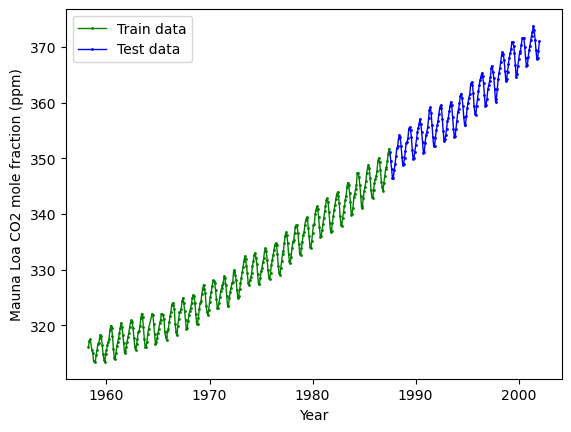

In [3]:
data_all = [x,y]
print(x.shape, y.shape)
nsplit = data_all[0].shape[0]//3*2
data_train = [x[:nsplit],y[:nsplit]]
data_test = [x[nsplit:],y[nsplit:]]

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(data_train[0], data_train[1], 'g.-', label='Train data', linewidth = 1, markersize=2)
ax.plot(data_test[0], data_test[1], 'b.-', label='Test data', linewidth = 1, markersize=2)
ax.set_xlabel("Year")
ax.set_ylabel("Mauna Loa CO2 mole fraction (ppm)")
ax.legend()
plt.show()

### Gaussian process regression

In [ ]:
# Create Single GP instance with training data set
model_singleGP = SingleGP(data = data_train)
# Optimize hyper parameters
model_singleGP.optimize()

print(model_singleGP)

Restart 1/4, f = 19.4576
Restart 2/4, f = 2.1502


In [ ]:
# Prediction
mean, var = model_singleGP.predict(x)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(data_train[0], data_train[1], 'g.-', label='Train data', linewidth = 1, markersize=2)
ax.plot(data_test[0], data_test[1], 'b.-', label='Test data', linewidth = 1, markersize=2)
ax.plot(x[:,0], mean[:,0], 'r', label = 'SingleGP prediction', linewidth = 1)
ax.fill_between(x[:,0], (mean[:,0]-2.0*np.sqrt(var[:,0])).ravel(), (mean[:,0]+2.0*np.sqrt(var[:,0])).ravel(), alpha=0.1, color='red')
ax.set_xlabel("Year")
ax.set_ylabel("Mauna Loa CO2 mole fraction (ppm)")
ax.legend()
plt.show()